
=== Обработка Шанхая (обучение) ===
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001027 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7245
[LightGBM] [Info] Number of data points in the train set: 2920, number of used features: 52
[LightGBM] [Info] Start training from score 0.493724
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002847 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7690
[LightGBM] [Info] Number of data points in the train set: 5840, number of used features: 52
[LightGBM] [Info] Start training from score 0.064606
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003707 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8291
[LightGBM]

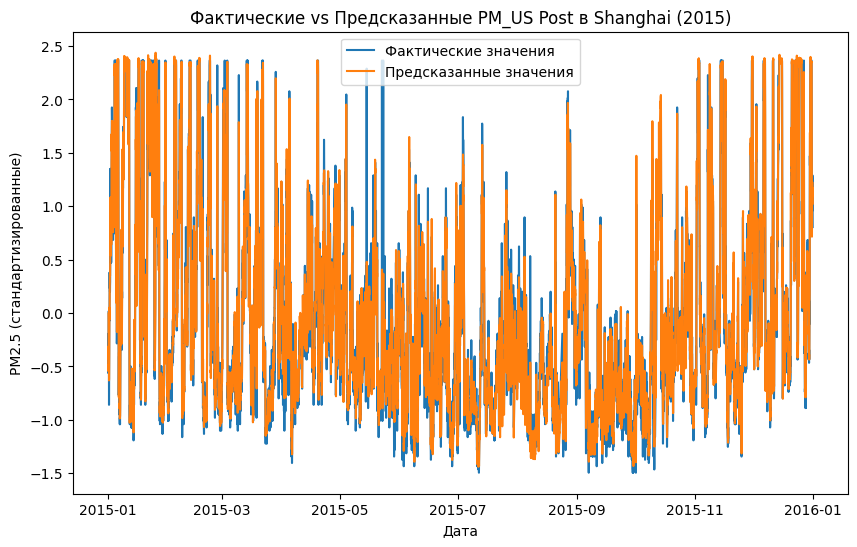


=== Обработка Beijing ===
Beijing - MAE: 1.0366, RMSE: 1.7910, R²: 0.3473


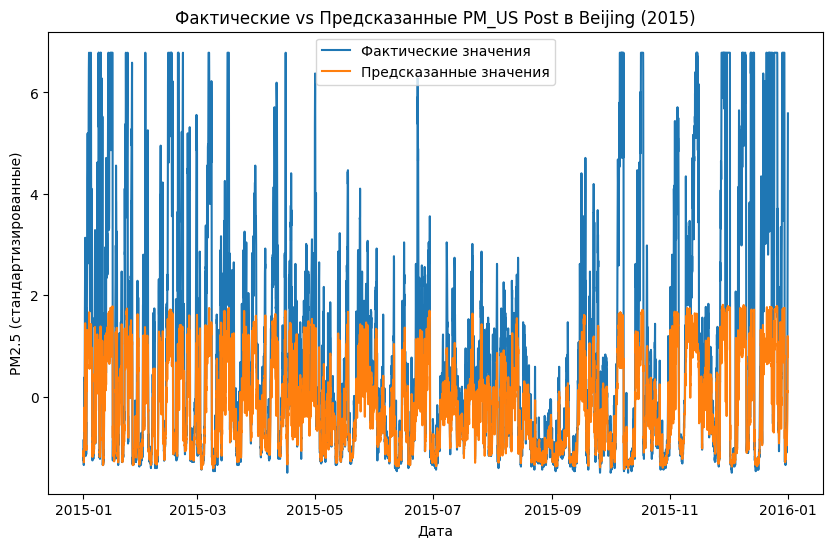


=== Обработка Chengdu ===
Chengdu - MAE: 0.6761, RMSE: 1.0078, R²: 0.4508


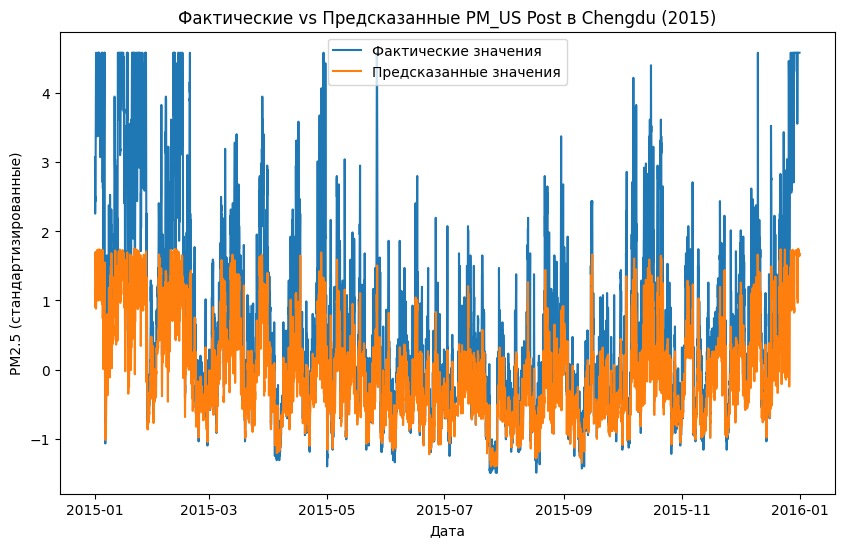


=== Обработка Guangzhou ===
Guangzhou - MAE: 0.2634, RMSE: 0.3749, R²: 0.7801


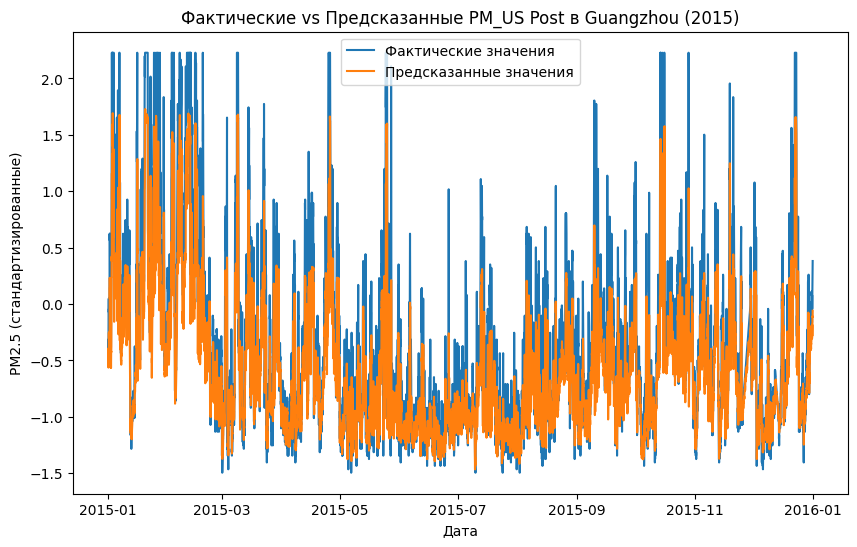


=== Обработка Shenyang ===
Shenyang - MAE: 0.7111, RMSE: 1.0061, R²: 0.5371


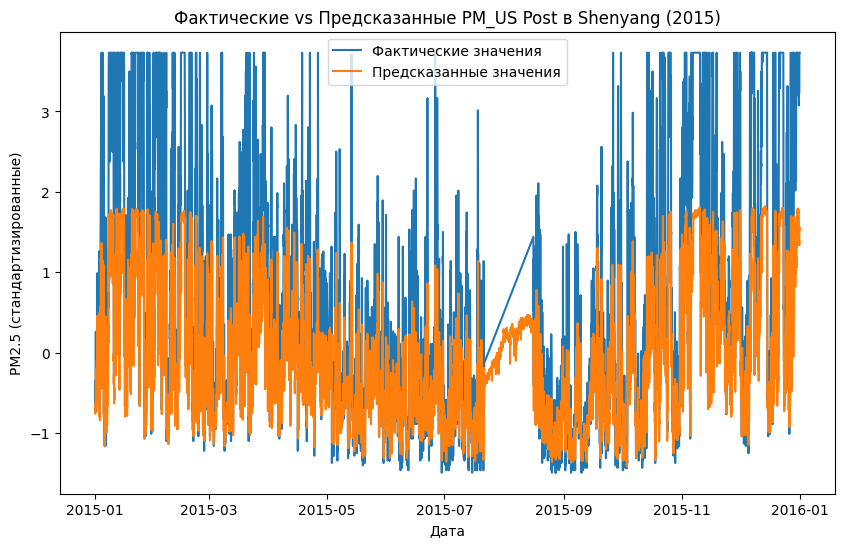

<Figure size 1000x600 with 0 Axes>

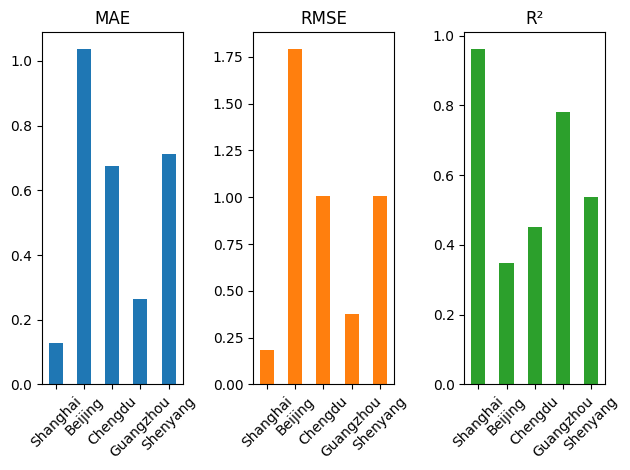


=== Финальные результаты ===
Shanghai: MAE=0.1279, RMSE=0.1850, R²=0.9615
Beijing: MAE=1.0366, RMSE=1.7910, R²=0.3473
Chengdu: MAE=0.6761, RMSE=1.0078, R²=0.4508
Guangzhou: MAE=0.2634, RMSE=0.3749, R²=0.7801
Shenyang: MAE=0.7111, RMSE=1.0061, R²=0.5371


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Функция для предобработки данных
def preprocess_data(df, scaler=None, fit_scaler=False):
    df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
    df.set_index('datetime', inplace=True)
    
    # Обработка пропущенных значений
    numeric_cols = ['PM_US Post', 'DEWP', 'HUMI', 'PRES', 'TEMP', 'Iws', 'precipitation', 'Iprec']
    for col in numeric_cols:
        if col in df.columns:
            df[col] = df[col].interpolate(method='linear')
            df[col] = df[col].fillna(df[col].mean())
    
    if 'cbwd' in df.columns:
        df['cbwd'] = df['cbwd'].fillna(df['cbwd'].mode()[0])
    
    df = df[df.index.year >= 2013]
    
    if 'cbwd' in df.columns:
        df = pd.get_dummies(df, columns=['cbwd'], prefix='cbwd')
    
    # Добавление временных признаков
    df['month_sin'] = np.sin(2 * np.pi * df.index.month / 12)
    df['month_cos'] = np.cos(2 * np.pi * df.index.month / 12)
    df['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)
    df['season'] = pd.Series(((df.index.month % 12 + 3) // 3), index=df.index).clip(1, 4)
    
    # Обработка выбросов
    cols = ['PM_US Post', 'PM_Jingan', 'PM_Xuhui', 'DEWP', 'HUMI', 'PRES', 'TEMP']
    for col in cols:
        if col in df.columns:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            df[col] = df[col].clip(lower_bound, upper_bound)
    
    # Специальная обработка для Iws с логарифмированием
    if 'Iws' in df.columns:
        # Логарифмирование (log1p для обработки нулевых значений)
        df['Iws_log'] = np.log1p(df['Iws'])
        Q1 = df['Iws_log'].quantile(0.25)
        Q3 = df['Iws_log'].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = max(0, Q1 - 1.5 * IQR)  # Устанавливаем минимум 0 в логарифмированном масштабе
        upper_bound = Q3 + 1.5 * IQR
        df['Iws_log'] = df['Iws_log'].clip(lower_bound, upper_bound)
        # Обратное преобразование в исходный масштаб
        df['Iws'] = np.expm1(df['Iws_log'])
        df = df.drop(columns=['Iws_log'])  # Удаляем временный столбец
    
    df = df.drop(columns=['No'], errors='ignore')
    
    if fit_scaler:
        scaler = StandardScaler()
        scaler.fit(df[numeric_cols])
    if scaler is not None:
        df[numeric_cols] = scaler.transform(df[numeric_cols])
    
    return df, numeric_cols, scaler

# Функция для создания новых признаков
def engineer_features(df):
    # Лаговые признаки только для PM_US Post
    if 'PM_US Post' in df.columns:
        for lag in [1, 3, 6, 12, 24]:
            df[f'PM_US Post_lag_{lag}'] = df['PM_US Post'].shift(lag)
    
    # Скользящие статистики для PM_US Post и погодных признаков
    for col in ['PM_US Post', 'DEWP', 'TEMP', 'HUMI', 'PRES', 'Iws']:
        if col in df.columns:
            for window in [6, 12]:
                df[f'{col}_ma_{window}'] = df[col].rolling(window=window).mean()
                df[f'{col}_std_{window}'] = df[col].rolling(window=window).std()
    
    # Заполнение пропущенных значений в новых признаках
    lag_ma_cols = [col for col in df.columns if 'lag' in col or 'ma' in col or 'std' in col]
    df[lag_ma_cols] = df[lag_ma_cols].fillna(df[lag_ma_cols].median())
    
    # Дополнительные признаки
    if 'TEMP' in df.columns and 'HUMI' in df.columns:
        df['TEMP_HUMI_interaction'] = df['TEMP'] * df['HUMI']
    df['is_winter'] = (df['season'] == 4).astype(float)
    
    return df

# Список городов и файлов
cities = ['Shanghai', 'Beijing', 'Chengdu', 'Guangzhou', 'Shenyang']
city_files = ['ShanghaiPM20100101_20151231.csv', 'BeijingPM20100101_20151231.csv', 
              'ChengduPM20100101_20151231.csv', 'GuangzhouPM20100101_20151231.csv', 
              'ShenyangPM20100101_20151231.csv']
results = {}

# Обработка и обучение на данных Шанхая
print("\n=== Обработка Шанхая (обучение) ===")
df_shanghai = pd.read_csv(city_files[0])
scaler = StandardScaler()
df_shanghai_processed, numeric_cols, scaler = preprocess_data(df_shanghai, scaler, fit_scaler=True)

train_df = df_shanghai_processed[df_shanghai_processed.index.year < 2015]
test_df_shanghai = df_shanghai_processed[df_shanghai_processed.index.year == 2015]

train_df = engineer_features(train_df)
test_df_shanghai = engineer_features(test_df_shanghai)

feature_cols = [col for col in train_df.columns if col != 'PM_US Post']
X_train = train_df[feature_cols].values.astype(np.float32)
y_train = train_df['PM_US Post'].values.astype(np.float32)

# Обучение модели
lgbm = LGBMRegressor(random_state=42)
param_grid = {
    'learning_rate': [0.05, 0.1, 0.15],
    'n_estimators': [200, 300, 400],
    'max_depth': [10, 15, 20],
    'num_leaves': [31, 50, 70],
    'min_child_samples': [20, 30, 40],
    'subsample': [0.8, 0.9, 1.0]
}
tscv = TimeSeriesSplit(n_splits=5)
random_search = RandomizedSearchCV(lgbm, param_grid, n_iter=20, cv=tscv, scoring='neg_mean_squared_error', random_state=42)
random_search.fit(X_train, y_train)
lgbm_best = random_search.best_estimator_
print(f"Шанхай - Лучшие параметры: {random_search.best_params_}")

# Оценка на всех городах
for city, city_file in zip(cities, city_files):
    print(f"\n=== Обработка {city} ===")
    try:
        df_city = pd.read_csv(city_file)
        df_city_processed, city_numeric_cols, _ = preprocess_data(df_city, scaler, fit_scaler=False)
        
        if 'PM_US Post' not in df_city_processed.columns:
            print(f"Пропуск {city}: PM_US Post отсутствует в датасете")
            continue
        
        df_city_processed = engineer_features(df_city_processed)
        
        # Обеспечение согласованности признаков
        missing_cols = [col for col in feature_cols if col not in df_city_processed.columns]
        for col in missing_cols:
            df_city_processed[col] = 0
        
        extra_cols = [col for col in df_city_processed.columns if col not in feature_cols and col != 'PM_US Post']
        df_city_processed = df_city_processed.drop(columns=extra_cols, errors='ignore')
        
        train_df_city = df_city_processed[df_city_processed.index.year < 2015]
        test_df_city = df_city_processed[df_city_processed.index.year == 2015]
        
        X_train_city = train_df_city[feature_cols].values.astype(np.float32)
        X_test_city = test_df_city[feature_cols].values.astype(np.float32)
        y_train_city = train_df_city['PM_US Post'].values.astype(np.float32)
        y_test_city = test_df_city['PM_US Post'].values.astype(np.float32)
        
        # Предсказание
        y_pred = lgbm_best.predict(X_test_city)
        
        mae = mean_absolute_error(y_test_city, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_city, y_pred))
        r2 = r2_score(y_test_city, y_pred)
        results[city] = {'MAE': mae, 'RMSE': rmse, 'R²': r2}
        
        print(f"{city} - MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")
        
        # Визуализация
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.plot(test_df_city.index, y_test_city, label='Фактические значения')
        ax.plot(test_df_city.index, y_pred, label='Предсказанные значения')
        ax.set_title(f'Фактические vs Предсказанные PM_US Post в {city} (2015)')
        ax.set_xlabel('Дата')
        ax.set_ylabel('PM2.5 (стандартизированные)')
        ax.legend()
        plt.show()
        
    except Exception as e:
        print(f"Ошибка при обработке {city}: {str(e)}")

# Визуализация
metrics_df = pd.DataFrame(results).T
plt.figure(figsize=(10, 6))
metrics_df.plot(kind='bar', subplots=True, layout=(1, 3), 
                title=['MAE', 'RMSE', 'R²'], 
                legend=False, rot=45)
plt.tight_layout()
plt.show()

# Вывод финальных результатов
print("\n=== Финальные результаты ===")
for city, metrics in results.items():
    print(f"{city}: MAE={metrics['MAE']:.4f}, RMSE={metrics['RMSE']:.4f}, R²={metrics['R²']:.4f}")